*© 2026 Paul Fergus*

# Lab 12 — Vision Transformers: attention instead of convolution

**Module:** 7144COMP — Deep Learning Concepts and Techniques
**Week:** 12
**Estimated time:** 240 minutes

---

## Learning outcomes

By the end of this lab you should be able to:

1. Explain how a Vision Transformer (ViT) turns an image into a sequence of patch embeddings, and why that allows self-attention to replace convolution entirely.
2. Implement scaled dot-product self-attention from first principles, and explain the role of the query, key, and value projections.
3. Explain positional encoding, and demonstrate empirically what breaks in a Transformer without it.
4. Fine-tune a pretrained ViT-B/16 and compare its accuracy against a CNN of comparable effort, on the same small data budget.
5. Train a ViT **from scratch** on that same small data budget and observe the data-hungriness gap this exposes, directly and empirically.
6. Visualise a ViT's attention map and contrast this native, built-in form of explanation against Lab 11's Grad-CAM, which needed extra machinery to extract an explanation from a CNN after the fact.

## Prerequisites

- **Lab 4** — CIFAR-10, the `CIFARCNN` architecture, and the overfitting/augmentation story we build on today.
- **Lab 11** — the explainability mindset; we contrast attention maps against Grad-CAM directly.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 8 — attention and Transformers.
- Lecture 12: *Self-attention and the Vision Transformer — trading inductive bias for scale*.

## The thread from last week

Lab 11 closed with a nod to where the module could go next: *"vision transformers, generative models, deployment at scale, foundation models bigger still than the ones in Lab 9 and Lab 10."* Today we follow the first of those threads. Every CNN in this module — Lab 3's digit classifier, Lab 4's CIFAR-10 network, Lab 5's malaria classifier, Lab 7's YOLO26 — shares an architectural assumption baked in from the first layer: **nearby pixels matter more than distant ones, and the same small filter should be applied everywhere.** That assumption is called an *inductive bias*, and it is not optional in a CNN — it is the architecture.

The Vision Transformer asks: what if we don't assume that? What if every part of the image can attend to every other part, from layer one, and the model has to *learn* whatever spatial structure matters, rather than have it assumed? The answer turns out to be a genuine trade-off, not a strict improvement — and today you will measure that trade-off yourself, not just read about it.

## Useful references

- Dosovitskiy, A. et al. (2021), *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* — the original ViT paper.
- Vaswani, A. et al. (2017), *Attention Is All You Need* — the Transformer paper self-attention comes from.
- [torchvision Vision Transformer documentation](https://docs.pytorch.org/vision/stable/models/vision_transformer.html)
- Jain, S. and Wallace, B.C. (2019), *Attention is not Explanation* — a critical counterpoint relevant to Section 8.

---

## 1. From convolution to attention

| | CNN (Labs 3, 4, 5, 7) | Vision Transformer (today) |
|---|---|---|
| What each layer looks at | a small local neighbourhood (the kernel) | the *entire* sequence of patches, everywhere, from layer 1 |
| How position is handled | implicit, via the sliding-kernel geometry | explicit — a learned positional embedding added to each patch |
| Parameter sharing | the same kernel weights reused at every spatial position | none by default — every patch's relationship to every other patch is learned freely |
| Inductive bias | strong: locality + translation equivariance, built into the architecture | weak: almost none built in; the model must learn spatial structure from data |
| Data efficiency | good with modest datasets (the bias does useful work for free) | needs either a lot of data or a lot of pretraining to learn what the CNN gets for free |

**Locality and translation equivariance**, the two ideas Lab 3 introduced for convolution, are the whole story here. A CNN's first layer physically cannot relate a pixel in the top-left corner to one in the bottom-right — not without many stacked layers growing the receptive field. A Transformer's first self-attention layer can relate *any* two patches immediately, at the cost of not knowing, out of the box, that nearby patches are usually more related than distant ones. Whether that trade is worth it depends entirely on how much data you have — which is exactly what Sections 5-7 measure.

## 2. Patch embeddings — turning an image into a sequence

A Transformer, at its core, operates on a **sequence of vectors**. It has no native notion of a 2D grid at all — that is what Section 1's table meant by "almost no inductive bias." ViT's contribution was a simple recipe for turning an image into a sequence:

1. **Split the image into fixed-size, non-overlapping patches** — e.g. 16x16 pixels each. A 224x224 image splits into a 14x14 grid of 196 patches.
2. **Flatten and linearly project each patch** into a `hidden_dim`-length embedding vector (768 for the ViT-B/16 model we use today) — precisely one token per patch, structurally identical to a word-embedding lookup in a text Transformer.
3. **Prepend a learnable `[CLS]` token** to the sequence. This token doesn't correspond to any patch; it's a placeholder whose final representation, after all the self-attention layers, is used for classification. It attends to (and is attended to by) every patch, so it's free to aggregate whatever information the model finds useful across the whole image.
4. **Add a learnable positional embedding** to every token (patch tokens and the `[CLS]` token) — Section 4 shows exactly why this step is not optional.
5. Feed the resulting sequence of 197 vectors through a standard Transformer encoder (alternating self-attention and MLP blocks). The final `[CLS]` token's vector goes to a linear classification head.

Let's see what "splitting into patches" actually looks like on a real image from our dataset.

PyTorch version: 2.11.0+cu128
Device: cuda


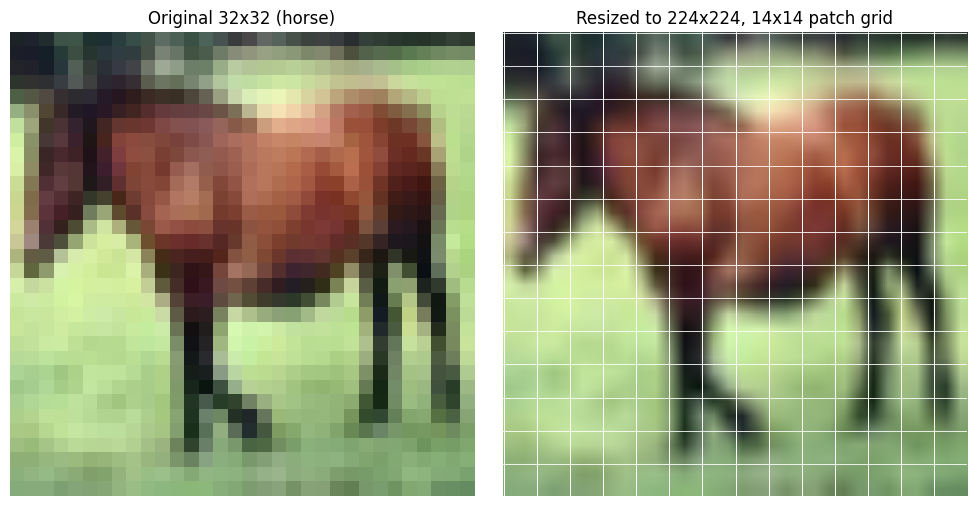

196 patches of 16x16 pixels, + 1 [CLS] token = 197 tokens in the sequence.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

RNG_SEED = 7144
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

# Reuse Lab 4's CIFAR-10 constants exactly, so our numbers stay comparable.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
CIFAR_CLASSES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

# Reuse Lab 4's already-downloaded CIFAR-10 cache instead of fetching a second
# copy — download=True is left on as a harmless fallback (torchvision checks
# the existing files' integrity first and skips re-downloading if they pass).
CIFAR_ROOT = "../lab04_cifar10_augmentation/data"
_raw = datasets.CIFAR10(root=CIFAR_ROOT, train=True, download=True, transform=transforms.ToTensor())
demo_img, demo_label = _raw[7]   # a fixed index so the figure is reproducible

PATCH = 16
UPSCALED = 224   # the resolution ViT-B/16's pretrained positional embeddings expect
demo_big = F.interpolate(demo_img.unsqueeze(0), size=UPSCALED, mode="bilinear", align_corners=False).squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(demo_img.permute(1, 2, 0)); axes[0].axis("off")
axes[0].set_title(f"Original 32x32 ({CIFAR_CLASSES[demo_label]})")

axes[1].imshow(demo_big.permute(1, 2, 0)); axes[1].axis("off")
axes[1].set_title(f"Resized to {UPSCALED}x{UPSCALED}, {UPSCALED//PATCH}x{UPSCALED//PATCH} patch grid")
for i in range(0, UPSCALED, PATCH):
    axes[1].add_patch(mpatches.Rectangle((i, 0), 0, UPSCALED, edgecolor="white", linewidth=0.6))
    axes[1].axvline(i, color="white", linewidth=0.6)
    axes[1].axhline(i, color="white", linewidth=0.6)
plt.tight_layout(); plt.show()

n_patches = (UPSCALED // PATCH) ** 2
print(f"{n_patches} patches of {PATCH}x{PATCH} pixels, + 1 [CLS] token = {n_patches + 1} tokens in the sequence.")

**Why resize a 32x32 CIFAR-10 image up to 224x224 at all?** Because the pretrained ViT-B/16 we fine-tune in Section 6 learned its positional embeddings at a fixed 14x14 patch grid, from ImageNet images shown at 224x224. This is a real, common practical constraint of transfer learning with ViTs — unlike a CNN, which is fully convolutional and can accept any input size, a standard ViT's positional embeddings are tied to a specific sequence length. We are trading detail (a 32x32 photo blown up to 224x224 does not gain real information) for compatibility with a model that already knows a great deal about natural images.

## 3. Self-attention, from first principles

Before loading a 86-million-parameter pretrained model, build the operation at its heart yourself — the same "understand it before you trust the library" discipline as Lab 8's IoU or Lab 10's mask IoU.

**Scaled dot-product self-attention**, given a sequence of `n` token embeddings of dimension `d`:

1. Project every token into a **query** (Q), **key** (K), and **value** (V) vector, via three learned linear layers.
2. For every pair of tokens `(i, j)`, compute a similarity score `Q_i . K_j` — how much token `i` should attend to token `j`.
3. Scale the scores by `1/sqrt(d)` (keeps the softmax well-behaved regardless of dimension) and softmax them across `j`, so each token's attention weights sum to 1.
4. Take the weighted sum of the **value** vectors using those weights — token `i`'s new representation is a blend of every other token's value, weighted by how relevant attention judged them to be.

`Attention(Q, K, V) = softmax(Q K^T / sqrt(d)) V`

That's the entire operation. No convolution, no locality assumption — token 0 and token 100 can interact just as directly as token 0 and token 1.

In [12]:
def self_attention(X: torch.Tensor, Wq: torch.Tensor, Wk: torch.Tensor, Wv: torch.Tensor):
    """Scaled dot-product self-attention on one sequence, from first principles.
    X: (n, d_in) token embeddings. Wq, Wk, Wv: (d_in, d_k) projection matrices.
    Returns (output (n, d_k), attention_weights (n, n)).
    """
    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv
    d_k = K.shape[-1]
    scores = (Q @ K.T) / (d_k ** 0.5)          # (n, n) raw similarity scores
    weights = F.softmax(scores, dim=-1)        # each row sums to 1
    output = weights @ V                       # weighted blend of value vectors
    return output, weights


# A toy sequence: 4 tokens, embedding dimension 8.
torch.manual_seed(RNG_SEED)
n_tokens, d_in, d_k = 4, 8, 6
X = torch.randn(n_tokens, d_in)
Wq = torch.randn(d_in, d_k) * 0.1
Wk = torch.randn(d_in, d_k) * 0.1
Wv = torch.randn(d_in, d_k) * 0.1

out, attn = self_attention(X, Wq, Wk, Wv)
print(f"Input shape:  {tuple(X.shape)}  (n_tokens, d_in)")
print(f"Output shape: {tuple(out.shape)}  (n_tokens, d_k)")
print(f"\nAttention weight matrix (each row sums to 1):")
print(attn.detach().numpy().round(3))
print(f"\nRow sums (should all be 1.0): {attn.sum(dim=-1).detach().numpy().round(4)}")

Input shape:  (4, 8)  (n_tokens, d_in)
Output shape: (4, 6)  (n_tokens, d_k)

Attention weight matrix (each row sums to 1):
[[0.237 0.263 0.249 0.251]
 [0.235 0.267 0.242 0.256]
 [0.246 0.252 0.255 0.247]
 [0.229 0.295 0.232 0.245]]

Row sums (should all be 1.0): [1. 1. 1. 1.]


**Reading the attention matrix.** Row `i`, column `j` is "how much token `i` attends to token `j`" — the diagonal is not necessarily the largest value (a token is not required to attend mostly to itself, unlike a residual/skip connection). With random, untrained weights this matrix looks close to uniform (roughly `1/n` everywhere); a *trained* model sharpens specific rows toward specific columns because doing so reduces the training loss. Real multi-head attention (what `nn.MultiheadAttention` and the pretrained ViT below actually use) simply runs several of these attention operations in parallel with different, smaller projection matrices, and concatenates the results — the mechanism is identical, just repeated with different learned "questions" per head.

## 4. What positional encoding actually buys you

Look again at the formula: `Attention(Q, K, V) = softmax(Q K^T / sqrt(d)) V`. Nowhere in it does the *order* of the tokens appear. If you permute the rows of `X` (shuffle the patches), the attention weights and outputs permute along with them — self-attention alone is **permutation-equivariant**, not sequence-aware. A Vision Transformer with no positional embedding literally cannot tell a photo from the same photo with its patches shuffled into a different arrangement; it would treat both as "the same bag of patches."

Let's demonstrate this directly, reusing the function you just wrote.

In [13]:
torch.manual_seed(RNG_SEED)
perm = torch.randperm(n_tokens)
X_shuffled = X[perm]

out_orig, _ = self_attention(X, Wq, Wk, Wv)
out_shuffled, _ = self_attention(X_shuffled, Wq, Wk, Wv)

# If self-attention is permutation-equivariant, permuting the OUTPUT of the
# original run the same way should exactly match the shuffled run's output.
out_orig_permuted = out_orig[perm]
max_diff = (out_orig_permuted - out_shuffled).abs().max().item()
print(f"Max difference between 'permute the output' and 'run on shuffled input': {max_diff:.2e}")
print("(Should be ~0 — self-attention has no idea the tokens were ever reordered.)")

Max difference between 'permute the output' and 'run on shuffled input': 2.98e-08
(Should be ~0 — self-attention has no idea the tokens were ever reordered.)


That near-zero difference is the whole point: self-attention genuinely cannot distinguish "patch A next to patch B" from "patch A far from patch B" — order and adjacency carry no information to it unless you *give* it that information explicitly. That's exactly what the learned positional embedding in Section 2 step 4 does: it adds a unique, learned vector to each token depending on *where* it sits in the sequence, so two otherwise-identical patches at different positions become distinguishable. Without it, a ViT would be no better than a bag-of-patches model — no matter how much data or how many attention layers you gave it.

This also explains why a pretrained ViT's positional embeddings are tied to a specific grid size (Section 2's note about 224x224): each embedding was learned for one specific patch position, in one specific arrangement.

## 5. Setting up a fair, small-data comparison

The rest of this lab runs a controlled experiment: train three models on the **exact same, deliberately small** slice of CIFAR-10, and see how each copes.

- **Lab 4's CNN**, retrained here on the small subset (its own inductive bias should let it cope reasonably).
- **A pretrained ViT-B/16**, fine-tuned on the small subset (ImageNet pretraining should compensate for the lack of inductive bias).
- **The same ViT-B/16 architecture, trained from random weights** on the small subset (no inductive bias *and* no pretraining — the case the lab predicts will struggle).

We keep the training subset small on purpose. Lab 4 already showed you what a CNN can do with all 45,000 training images; today's question is what happens when data is scarce, which is the situation most real projects are actually in.

In [14]:
from torch.utils.data import DataLoader, Subset

# Small-data budget, shared by all three models in this lab.
SUBSET_TRAIN = 4000
SUBSET_VAL = 800

cifar_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
vit_eval_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_full_cnn = datasets.CIFAR10(root=CIFAR_ROOT, train=True, download=False, transform=cifar_eval_transform)
train_full_vit = datasets.CIFAR10(root=CIFAR_ROOT, train=True, download=False, transform=vit_eval_transform)
test_set_cnn = datasets.CIFAR10(root=CIFAR_ROOT, train=False, download=False, transform=cifar_eval_transform)
test_set_vit = datasets.CIFAR10(root=CIFAR_ROOT, train=False, download=False, transform=vit_eval_transform)

rng = np.random.default_rng(RNG_SEED)
subset_idx = rng.choice(len(train_full_cnn), size=SUBSET_TRAIN + SUBSET_VAL, replace=False)
train_idx, val_idx = subset_idx[:SUBSET_TRAIN], subset_idx[SUBSET_TRAIN:]

BATCH_SIZE = 32
train_loader_cnn = DataLoader(Subset(train_full_cnn, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn = DataLoader(Subset(train_full_cnn, val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn = DataLoader(test_set_cnn, batch_size=BATCH_SIZE, shuffle=False)

train_loader_vit = DataLoader(Subset(train_full_vit, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader_vit = DataLoader(Subset(train_full_vit, val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader_vit = DataLoader(test_set_vit, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training subset:   {SUBSET_TRAIN} images")
print(f"Validation subset: {SUBSET_VAL} images")
print(f"Test set (full):   {len(test_set_cnn)} images")
print("\nSame indices used for both the 32x32 (CNN) and 224x224 (ViT) versions,")
print("so all three models see literally the same photographs.")

Training subset:   4000 images
Validation subset: 800 images
Test set (full):   10000 images

Same indices used for both the 32x32 (CNN) and 224x224 (ViT) versions,
so all three models see literally the same photographs.


## 6. Baseline — Lab 4's CNN, retrained on the small subset

Identical architecture and training loop to Lab 4, just pointed at the reduced training set. This is the inductive-bias half of the comparison: does locality + parameter sharing let a CNN cope reasonably with 4,000 images?

In [15]:
class CIFARCNN(nn.Module):
    """Identical to Lab 4's architecture."""

    def __init__(self, n_classes: int = 10, dropout: float = 0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


class EarlyStopping:
    def __init__(self, patience: int = 4, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.epochs_without_improvement = 0
        self.best_state = None
        self.should_stop = False

    def step(self, current_loss: float, model: nn.Module) -> None:
        if current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.epochs_without_improvement = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                self.should_stop = True

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(mode=is_train)
    total_loss, total_correct, total_samples = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_samples += xb.size(0)
    return total_loss / total_samples, total_correct / total_samples


import time

def train_model(model, train_loader, val_loader, max_epochs, lr=1e-3, patience=4, label="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    es = EarlyStopping(patience=patience)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    print(f"\n=== Training {label} for up to {max_epochs} epochs ===")
    t0 = time.perf_counter()
    for epoch in range(1, max_epochs + 1):
        tl, ta = run_epoch(model, train_loader, criterion, optimizer)
        vl, va = run_epoch(model, val_loader, criterion, optimizer=None)
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl); history["val_acc"].append(va)
        print(f"epoch {epoch:>2d}  |  train loss {tl:.4f} acc {ta:.4f}  |  val loss {vl:.4f} acc {va:.4f}")
        es.step(vl, model)
        if es.should_stop:
            print(f"Early stopping at epoch {epoch}.")
            break
    es.restore_best(model)
    model.to(DEVICE)
    print(f"Done in {(time.perf_counter() - t0)/60:.1f} min. Best val loss: {es.best_loss:.4f}")
    return history


torch.manual_seed(RNG_SEED)
model_cnn = CIFARCNN().to(DEVICE)
history_cnn = train_model(model_cnn, train_loader_cnn, val_loader_cnn,
                           max_epochs=15, label=f"CNN on {SUBSET_TRAIN} images")


=== Training CNN on 4000 images for up to 15 epochs ===
epoch  1  |  train loss 1.9452 acc 0.2913  |  val loss 1.6169 acc 0.3812
epoch  2  |  train loss 1.6186 acc 0.3940  |  val loss 1.4524 acc 0.4763
epoch  3  |  train loss 1.4688 acc 0.4555  |  val loss 1.3856 acc 0.5025
epoch  4  |  train loss 1.3715 acc 0.4930  |  val loss 1.3078 acc 0.5325
epoch  5  |  train loss 1.2618 acc 0.5350  |  val loss 1.4112 acc 0.5038
epoch  6  |  train loss 1.1860 acc 0.5687  |  val loss 1.2866 acc 0.5463
epoch  7  |  train loss 1.1006 acc 0.5960  |  val loss 1.1753 acc 0.5863
epoch  8  |  train loss 0.9845 acc 0.6438  |  val loss 1.1174 acc 0.6125
epoch  9  |  train loss 0.9152 acc 0.6665  |  val loss 1.0910 acc 0.6212
epoch 10  |  train loss 0.8870 acc 0.6810  |  val loss 1.1685 acc 0.6088
epoch 11  |  train loss 0.7523 acc 0.7177  |  val loss 1.1787 acc 0.6075
epoch 12  |  train loss 0.6990 acc 0.7455  |  val loss 1.0843 acc 0.6338
epoch 13  |  train loss 0.6562 acc 0.7538  |  val loss 1.0895 acc 0

## 7. Loading a pretrained ViT-B/16

`torchvision` ships ViT-B/16 with ImageNet-pretrained weights — nothing new to install. "B/16" means the **B**ase-sized variant with **16x16** patches (86M parameters, 768-dim embeddings, 12 layers, 12 attention heads per layer — the same scale class as YOLO26x, for comparison).

We replace the final classification head (originally 1,000 ImageNet classes) with a fresh linear layer for our 10 CIFAR-10 classes — exactly the transfer-learning move Lab 7 made with YOLO26's pretrained COCO head.

In [6]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

def build_vit(pretrained: bool) -> nn.Module:
    """Build a ViT-B/16 with a fresh 10-class head. pretrained=False gives random init."""
    weights = ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
    model = vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, len(CIFAR_CLASSES))
    return model.to(DEVICE)


vit_pretrained = build_vit(pretrained=True)
n_params = sum(p.numel() for p in vit_pretrained.parameters())
print(f"ViT-B/16 parameters: {n_params:,}")
print(f"Patch size: {vit_pretrained.patch_size}, hidden dim: {vit_pretrained.hidden_dim}")
print(f"Encoder layers: {len(vit_pretrained.encoder.layers)}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/student/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:18<00:00, 18.5MB/s] 


ViT-B/16 parameters: 85,806,346
Patch size: 16, hidden dim: 768
Encoder layers: 12


## 8. Fine-tuning the pretrained ViT on the small subset

> ⏱ **Time estimate.** ViT-B/16 at 224x224 is far more expensive per image than the tiny CNN — expect roughly 10-20x the wall-clock time per epoch on the same GPU. On a 4,000-image subset this should still only be a few minutes per epoch on a 3090/4090/5090; on CPU, expect it to be genuinely slow, and you may want to reduce `max_epochs` below.

We fine-tune the *whole* model (not just the head) with a small learning rate, the same "adjust, don't overwrite" logic Lab 7's reflection questions covered for YOLO26.

In [16]:
torch.manual_seed(RNG_SEED)
history_vit_pretrained = train_model(
    vit_pretrained, train_loader_vit, val_loader_vit,
    max_epochs=6, lr=3e-5, patience=3,
    label=f"pretrained ViT-B/16 on {SUBSET_TRAIN} images"
)


=== Training pretrained ViT-B/16 on 4000 images for up to 6 epochs ===
epoch  1  |  train loss 0.0436 acc 0.9875  |  val loss 0.2239 acc 0.9363
epoch  2  |  train loss 0.0183 acc 0.9945  |  val loss 0.2269 acc 0.9325
epoch  3  |  train loss 0.0345 acc 0.9898  |  val loss 0.2285 acc 0.9363
epoch  4  |  train loss 0.0302 acc 0.9928  |  val loss 0.2770 acc 0.9187
Early stopping at epoch 4.
Done in 1.1 min. Best val loss: 0.2239


## 9. The same architecture, from random weights

Now the crux of the experiment: identical model, identical data, identical training budget — the *only* difference is starting from random weights instead of ImageNet pretraining. If the inductive-bias argument from Section 1 is right, this run should struggle far more than either the CNN or the pretrained ViT.

In [17]:
torch.manual_seed(RNG_SEED)
vit_scratch = build_vit(pretrained=False)
history_vit_scratch = train_model(
    vit_scratch, train_loader_vit, val_loader_vit,
    max_epochs=15, lr=3e-4, patience=5,
    label=f"from-scratch ViT-B/16 on {SUBSET_TRAIN} images"
)


=== Training from-scratch ViT-B/16 on 4000 images for up to 15 epochs ===
epoch  1  |  train loss 2.2421 acc 0.1845  |  val loss 2.0678 acc 0.2200
epoch  2  |  train loss 2.0438 acc 0.2345  |  val loss 1.9411 acc 0.2650
epoch  3  |  train loss 1.9841 acc 0.2512  |  val loss 1.9158 acc 0.2550
epoch  4  |  train loss 1.9391 acc 0.2727  |  val loss 2.0022 acc 0.2412
epoch  5  |  train loss 1.9252 acc 0.2705  |  val loss 1.8809 acc 0.2838
epoch  6  |  train loss 1.8866 acc 0.2777  |  val loss 1.8590 acc 0.2812
epoch  7  |  train loss 1.8441 acc 0.2880  |  val loss 1.8724 acc 0.2925
epoch  8  |  train loss 1.8547 acc 0.2913  |  val loss 1.8591 acc 0.2888
epoch  9  |  train loss 1.8081 acc 0.3073  |  val loss 1.8345 acc 0.3013
epoch 10  |  train loss 1.8093 acc 0.3185  |  val loss 1.9277 acc 0.2787
epoch 11  |  train loss 1.8020 acc 0.3132  |  val loss 1.8450 acc 0.3100
epoch 12  |  train loss 1.7797 acc 0.3267  |  val loss 1.8337 acc 0.3063
epoch 13  |  train loss 1.7931 acc 0.3192  |  val

## 10. The comparison

All three models trained on the same 4,000 images. Time to see the story the numbers tell.

Model                         Test accuracy
-------------------------------------------
CNN (from scratch)                   0.6135
ViT-B/16 (pretrained)                0.9558
ViT-B/16 (from scratch)              0.3389


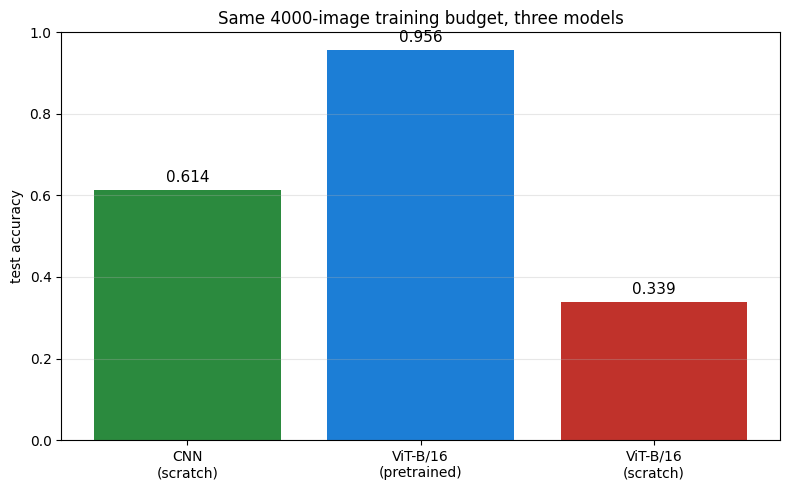


For context, Lab 4's CNN trained on the FULL 45,000-image training set
reached roughly 0.74-0.78 test accuracy — enter your own Lab 4 number here to compare:


In [9]:
def evaluate_test(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return correct / total


test_acc_cnn = evaluate_test(model_cnn, test_loader_cnn)
test_acc_vit_pretrained = evaluate_test(vit_pretrained, test_loader_vit)
test_acc_vit_scratch = evaluate_test(vit_scratch, test_loader_vit)

print(f"{'Model':<28s}{'Test accuracy':>15s}")
print("-" * 43)
print(f"{'CNN (from scratch)':<28s}{test_acc_cnn:>15.4f}")
print(f"{'ViT-B/16 (pretrained)':<28s}{test_acc_vit_pretrained:>15.4f}")
print(f"{'ViT-B/16 (from scratch)':<28s}{test_acc_vit_scratch:>15.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
names = ["CNN\n(scratch)", "ViT-B/16\n(pretrained)", "ViT-B/16\n(scratch)"]
vals = [test_acc_cnn, test_acc_vit_pretrained, test_acc_vit_scratch]
colours = ["#2b8a3e", "#1c7ed6", "#c0322b"]
bars = ax.bar(names, vals, color=colours)
ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1)
ax.set_title(f"Same {SUBSET_TRAIN}-image training budget, three models")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nFor context, Lab 4's CNN trained on the FULL 45,000-image training set")
print("reached roughly 0.74-0.78 test accuracy — enter your own Lab 4 number here to compare:")
lab4_full_cnn_acc = None   # EDIT: paste your Lab 4 augmented-model test accuracy here
if lab4_full_cnn_acc is not None:
    print(f"Lab 4 CNN, full 45,000 images: {lab4_full_cnn_acc:.4f}")

**Reading this.** The expected pattern: the **pretrained ViT** does well despite the small subset — ImageNet pretraining already taught it what edges, textures, and object parts look like, so 4,000 fine-tuning images is enough to adapt that knowledge to CIFAR-10's ten classes. The **CNN** does respectably too — its inductive bias means it doesn't need to *discover* locality from data, only to learn what patterns matter within that assumption. The **from-scratch ViT** is the one that should visibly struggle — with no inductive bias and no pretraining, it has to learn *everything*, including facts as basic as "nearby pixels tend to be related," purely from 4,000 examples, and that is generally not enough.

If your own numbers don't show this pattern cleanly, that is itself worth investigating (small-subset runs are noisier — try a different `RNG_SEED` for the subset selection, or increase `SUBSET_TRAIN` and see whether the gap changes) rather than being a sign your code is broken.

## 11. Seeing what the ViT is looking at — attention maps

Lab 11 needed a whole apparatus — forward and backward hooks, gradient-weighted channel combination, ReLU — to prise a post-hoc explanation out of a CNN that was never designed to be transparent. A Transformer's attention weights are different in kind: they are not reconstructed after the fact, they are *literally numbers the model computed on the way to its answer*. The `[CLS]` token's attention to every patch, in the final layer, is a direct readout of which parts of the image most informed the classification decision.

We need one small hook to capture it, because `torchvision`'s ViT discards attention weights by default (they're expensive to keep for every layer) — but unlike Grad-CAM, we don't need gradients or a backward pass at all, just a look at what the forward pass already computed.

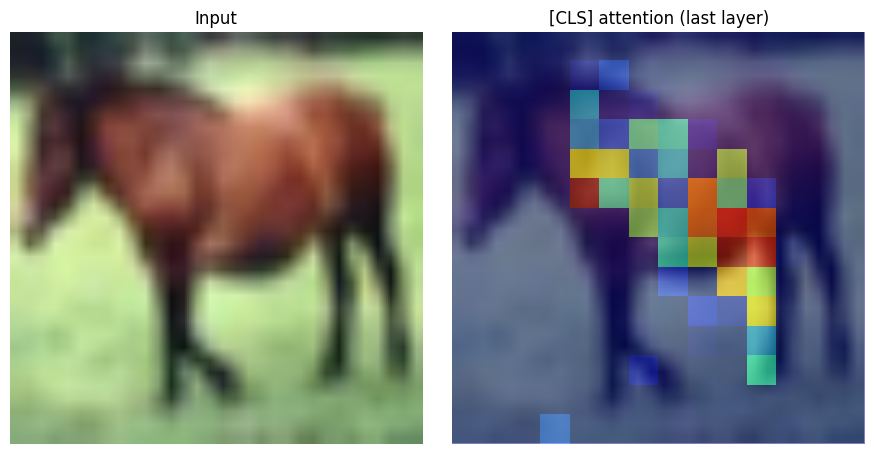

In [18]:
def get_cls_attention(model: nn.Module, x: torch.Tensor) -> np.ndarray:
    """Attention from the [CLS] token to every patch, in the model's LAST encoder layer.
    x: a single preprocessed image tensor (C, H, W), no batch dim.
    Returns a (grid, grid) numpy array, e.g. (14, 14) for ViT-B/16 at 224x224.

    Note: this reaches into torchvision's internal module structure
    (model.encoder.layers[-1].self_attention / .ln_1). If this breaks on a
    different torchvision version, run `print(model.encoder.layers[-1])` to
    find the equivalent submodule names.
    """
    model.eval()
    last_block = model.encoder.layers[-1]
    captured = {}

    def capture_input(module, inputs):
        captured["x"] = inputs[0]

    handle = last_block.register_forward_pre_hook(capture_input)
    with torch.no_grad():
        model(x.unsqueeze(0).to(DEVICE))
    handle.remove()

    with torch.no_grad():
        normed = last_block.ln_1(captured["x"])
        _, attn_weights = last_block.self_attention(
            normed, normed, normed, need_weights=True, average_attn_weights=True
        )
    # attn_weights: (1, seq_len, seq_len). Row 0 = the [CLS] token's query;
    # columns 1: are the patch tokens (column 0 is [CLS] attending to itself).
    cls_to_patches = attn_weights[0, 0, 1:].cpu().numpy()
    grid_size = int(round(len(cls_to_patches) ** 0.5))
    return cls_to_patches.reshape(grid_size, grid_size)


# Try it on the demo image from Section 2.
demo_vit_input = vit_eval_transform(
    datasets.CIFAR10(root=CIFAR_ROOT, train=False, download=False)[7][0]
)
attn_map = get_cls_attention(vit_pretrained, demo_vit_input)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
disp = demo_big.permute(1, 2, 0).numpy()
axes[0].imshow(disp); axes[0].axis("off"); axes[0].set_title("Input")
axes[1].imshow(disp)
axes[1].imshow(attn_map, cmap="jet", alpha=0.5, extent=(0, UPSCALED, UPSCALED, 0))
axes[1].axis("off"); axes[1].set_title("[CLS] attention (last layer)")
plt.tight_layout(); plt.show()

**Comparing this to Lab 11's Grad-CAM.** Both produce a heatmap over the image, but they answer subtly different questions. Grad-CAM asks: *if I nudge this region, how much does the predicted class score change?* — an output-sensitivity question, answered via gradients. The attention map asks: *how much did the `[CLS]` token's representation draw on this region, mechanically, during the forward pass?* — a description of the computation, not of output sensitivity. These usually agree in broad strokes but are not the same thing, which is exactly what Reflection Q3 asks you to think through.

---

## 12. Exercise 1 — patch size trade-off

`torchvision` also ships `vit_b_32` — the same architecture, but with 32x32 patches instead of 16x16 (so a 224x224 image becomes a 7x7 = 49-patch sequence instead of 14x14 = 196).

1. Repeat Section 8's fine-tuning run (pretrained, same subset, same hyperparameters) using `torchvision.models.vit_b_32` with `ViT_B_32_Weights.IMAGENET1K_V1` instead of `vit_b_16`.
2. Compare test accuracy, training time per epoch, and parameter count against the `vit_b_16` result from Section 10.
3. Larger patches mean a *shorter* sequence (fewer tokens for self-attention to relate) but *coarser* spatial resolution (each token covers a bigger, less precise region). Which effect dominates on CIFAR-10, and why might that make sense given how small the original 32x32 images actually are?

In [ ]:
# Your code for Exercise 1 here.

*Your findings on patch size:*

## 13. Exercise 2 — diagnose the from-scratch ViT's mistakes

Do **all three** of the following, using `vit_scratch` from Section 9.

**(a)** Compute per-class test accuracy for the from-scratch ViT. Which classes does it do *least* badly on? Is there a pattern (e.g. visually simple/distinctive classes vs visually complex ones)?

**(b)** Pick 4 test images the from-scratch ViT gets wrong. Render their attention maps using `get_cls_attention` from Section 11. Does the attention look structured (focused on the animal/object) or diffuse and scattered? What would you expect, given how little data it was trained on?

**(c)** Render the attention maps for the *same* 4 images through the *pretrained* ViT from Section 8. Compare. Is the pretrained model's attention visibly more focused?

In [ ]:
# Your code for Exercise 2 (a), (b), (c) here.

*Your findings:*

(a)

(b)

(c)

## 14. Exercise 3 — open-ended (pick one)

**Option A — Where does the crossover happen?** Repeat Sections 6, 8, and 9 at a few different subset sizes (e.g. 500, 2,000, 4,000, 15,000 images). Plot test accuracy vs. subset size for all three models on the same axes. At what dataset size, if any, does the from-scratch ViT catch up to the CNN? Does the pretrained ViT's advantage shrink as data grows?

**Option B — Freeze vs. fully fine-tune.** Repeat Section 8, but freeze every parameter except `model.heads.head` (a *linear probe* — set `param.requires_grad = False` for everything else). Compare accuracy, training time, and GPU memory against the fully fine-tuned Section 8 run. Is the frozen version competitive? When would you choose it in practice?

**Option C — Does removing positional embeddings hurt a trained model?** Take the fine-tuned `vit_pretrained` model from Section 8. Find its positional embedding parameter (`vit_pretrained.encoder.pos_embedding` in `torchvision`'s implementation — print `[n for n, _ in vit_pretrained.named_parameters() if "pos" in n]` to confirm the name in your version). Zero it out (or replace it with random noise) and re-run Section 10's test evaluation *without retraining*. How much does accuracy drop? This turns Section 4's toy permutation demo into a real measurement on a real trained model.

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.

*Which option did you pick, and what did you find?*

---

## 15. Reflection questions

**Q1.** In your own words, explain the CNN inductive bias (locality + weight sharing) from Section 1, and state precisely what a Vision Transformer lacks that a CNN has built in from its first layer.

**Q2.** Look at your own Section 10 results. Was pretraining necessary for the ViT to be competitive with the CNN on your small subset? What does this imply for a team wanting to use a ViT on a small, proprietary dataset with no ability to pretrain at ImageNet scale themselves?

**Q3.** Section 11 contrasted attention maps against Lab 11's Grad-CAM. A high attention weight from the `[CLS]` token to a patch tells you the model's computation *drew on* that patch — but does that necessarily mean that patch was *causally important* to the final prediction, the way Grad-CAM's gradient-based measure is by construction? Give one reason to be skeptical that "high attention" and "important for the decision" are always the same thing.

**Q4.** Imagine you're designing an image classifier for a wildlife camera-trap deployment like the one in Labs 6-10, with roughly 1,500 hand-annotated images and no realistic way to pretrain on ImageNet-scale data yourselves. Based on evidence from *this* lab, would you reach for a CNN or a ViT? Under what condition would your answer flip?

**Q5.** Section 4 showed that self-attention needs positional embeddings to be told about spatial structure at all — without them, it cannot tell "adjacent" from "far apart." Name one other place in this module where a model needed structure to be told to it explicitly, rather than being free to discover it from raw data alone, and explain the parallel.

*Your answers:*

**A1.**

**A2.**

**A3.**

**A4.**

**A5.**

---

## What's next

You've now seen the two dominant architecture families in computer vision side by side, on a controlled, honest comparison — not just read about the trade-off, but measured it. **Lab 13** goes further into the foundation-model direction Lab 9 opened: it opens up CLIP's contrastive image-text training — the same vision-language backbone behind Lab 9's YOLOE prompts, which you used without ever calling `import clip` yourself — to understand multi-modal embeddings directly, build a zero-shot classifier from scratch, and build a working text-to-image search engine. **Lab 14** then looks at generative models (autoencoders, GANs) as a genuinely different family of problem — not "what is in this image" but "produce a new, plausible one." The same question this lab taught you to ask keeps applying to both: **what inductive bias does this architecture assume, and does my data and problem actually match that assumption?**

Before leaving today, make sure:

- [ ] You implemented self-attention from first principles and ran the permutation demo
- [ ] You trained all three models (CNN, pretrained ViT, from-scratch ViT) on the same subset and compared test accuracy
- [ ] You rendered at least one attention map and compared it conceptually against Lab 11's Grad-CAM
- [ ] You completed Exercises 1, 2, and 3
- [ ] You answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors**